# Praxisbeispiel - Telko Kundenabgang-Vorhersage (Telco Customer Churn Prediction) bei Vertragskunden

Die Vorhersage der Kundenabwanderung (bei Vertragssituationen) sagt die Wahrscheinlichkeit voraus, dass Kunden die Produkte oder Dienstleistungen eines Unternehmens kündigen. 
In den meisten Fällen sind Unternehmen mit Stammkunden oder Kunden im Abonnement bestrebt, ihren Kundenstamm zu erhalten. Daher ist es wichtig, die Kunden zu verfolgen, die ihr Abonnement kündigen, und diejenigen, die den Dienst weiter nutzen. Dieser Ansatz setzt voraus, dass das Unternehmen das Verhalten seiner Kunden kennt und versteht und die Eigenschaften, die zu dem Risiko führen, dass der Kunde das Unternehmen verlässt. 


## Szenario

Annahme: Wir sind ein Telekommunikations-Unternehmen, das über historische Daten darüber verfügt, wie seine Kunden mit seinen Dienstleistungen interagiert haben. Das Unternehmen möchte wissen, wie hoch die Wahrscheinlichkeit ist, dass Kunden abwandern, damit es gezielte Marketingkampagnen starten kann.


## Datensatz 
Sage Kundenverhalten voraus, um die Kunden zu binden. 
Sie können alle relevanten Kundendaten analysieren und gezielte Kundenbindungsprogramme entwickeln.“ 

https://www.kaggle.com/datasets/blastchar/telco-customer-churn 

In [1]:
import sys
# !{sys.executable} -m pip install kagglehub
# !{sys.executable} -m pip install @
# !{sys.executable} -m pip install missingno

In [2]:
import kagglehub

In [3]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier

In [5]:
# Download data from Kaggle
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to files:", path)

Path to files: /Users/minye/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [6]:
path_file = "~/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv"
print(path_file)

~/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Datensatz 

In [7]:
df = pd.read_csv(path_file)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Der Datensatz enthält Informationen über:

- ob der Kunde innerhalb des letzten Monats gekündigt hat - Spalte "Churn"

- Dienste, für die sich jeder Kunde angemeldet hat - "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport" sowie "StreamingTV" und "StreamingMovies". 

- Informationen zum Kundenkonto - "tenure" wie lange der Kunde bereits Kunde ist, "Contract" (Vertrag), "PaperlessBilling" (papierlose Abrechnung), "PaymentMethod" (Zahlungsmethode), "MonthlyCharges" (monatliche Gebühren) und "TotalCharges" (Gesamtgebühren).

- Demografische Informationen über Kunden - "gender" (Geschlecht), "SeniorCitizen" (Alter) und ob sie "Partner" (Partner) und "Dependents" (Familienangehörige) haben.

In [8]:
print("shape: ", df.shape)
print()

print(df.info())

shape:  (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

## ACHTUNG!! 

Wir sehen, dass "TotalCharges" hier als object auftaucht, erwarten hier aber einen numerischen Typ.
Das muss geändert werden - wir zeigen euch aber erst, was passiert, wenn wir es nicht ändern.

In [9]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [10]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Ermittle fehlende Werte und visualisiere sie

In [11]:
## wir kannten schon die isnull() Funktion in pandas

for col in df.columns:
    print(col, df[col].isnull().sum())

customerID 0
gender 0
SeniorCitizen 0
Partner 0
Dependents 0
tenure 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
MonthlyCharges 0
TotalCharges 0
Churn 0


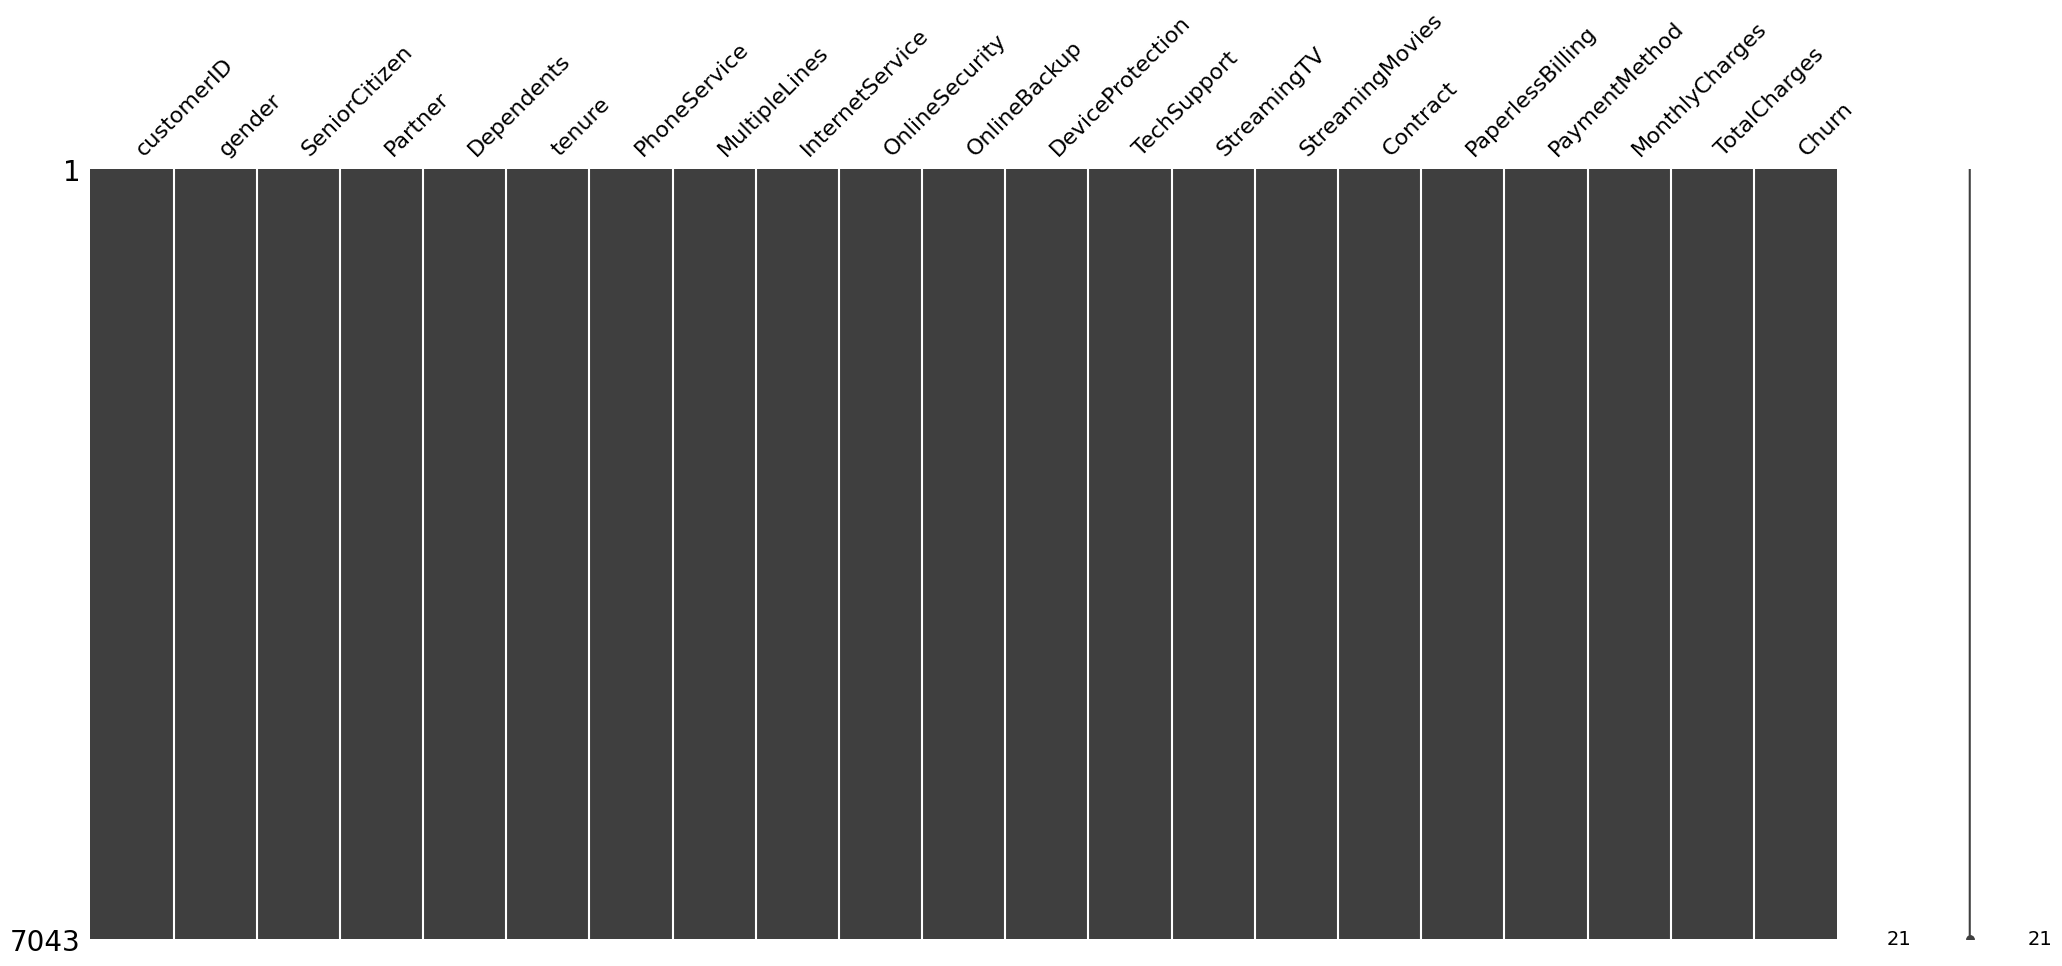

In [12]:
# Zudem könnte man sich die fehlende Werte auch in einer Matrix anzeigen lassen 
# (nur haben wir hier keine fehlenden Werte)

msno.matrix(df);

## Daten Manipulation / Bereinigung

In [13]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
# print(df.dtypes)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


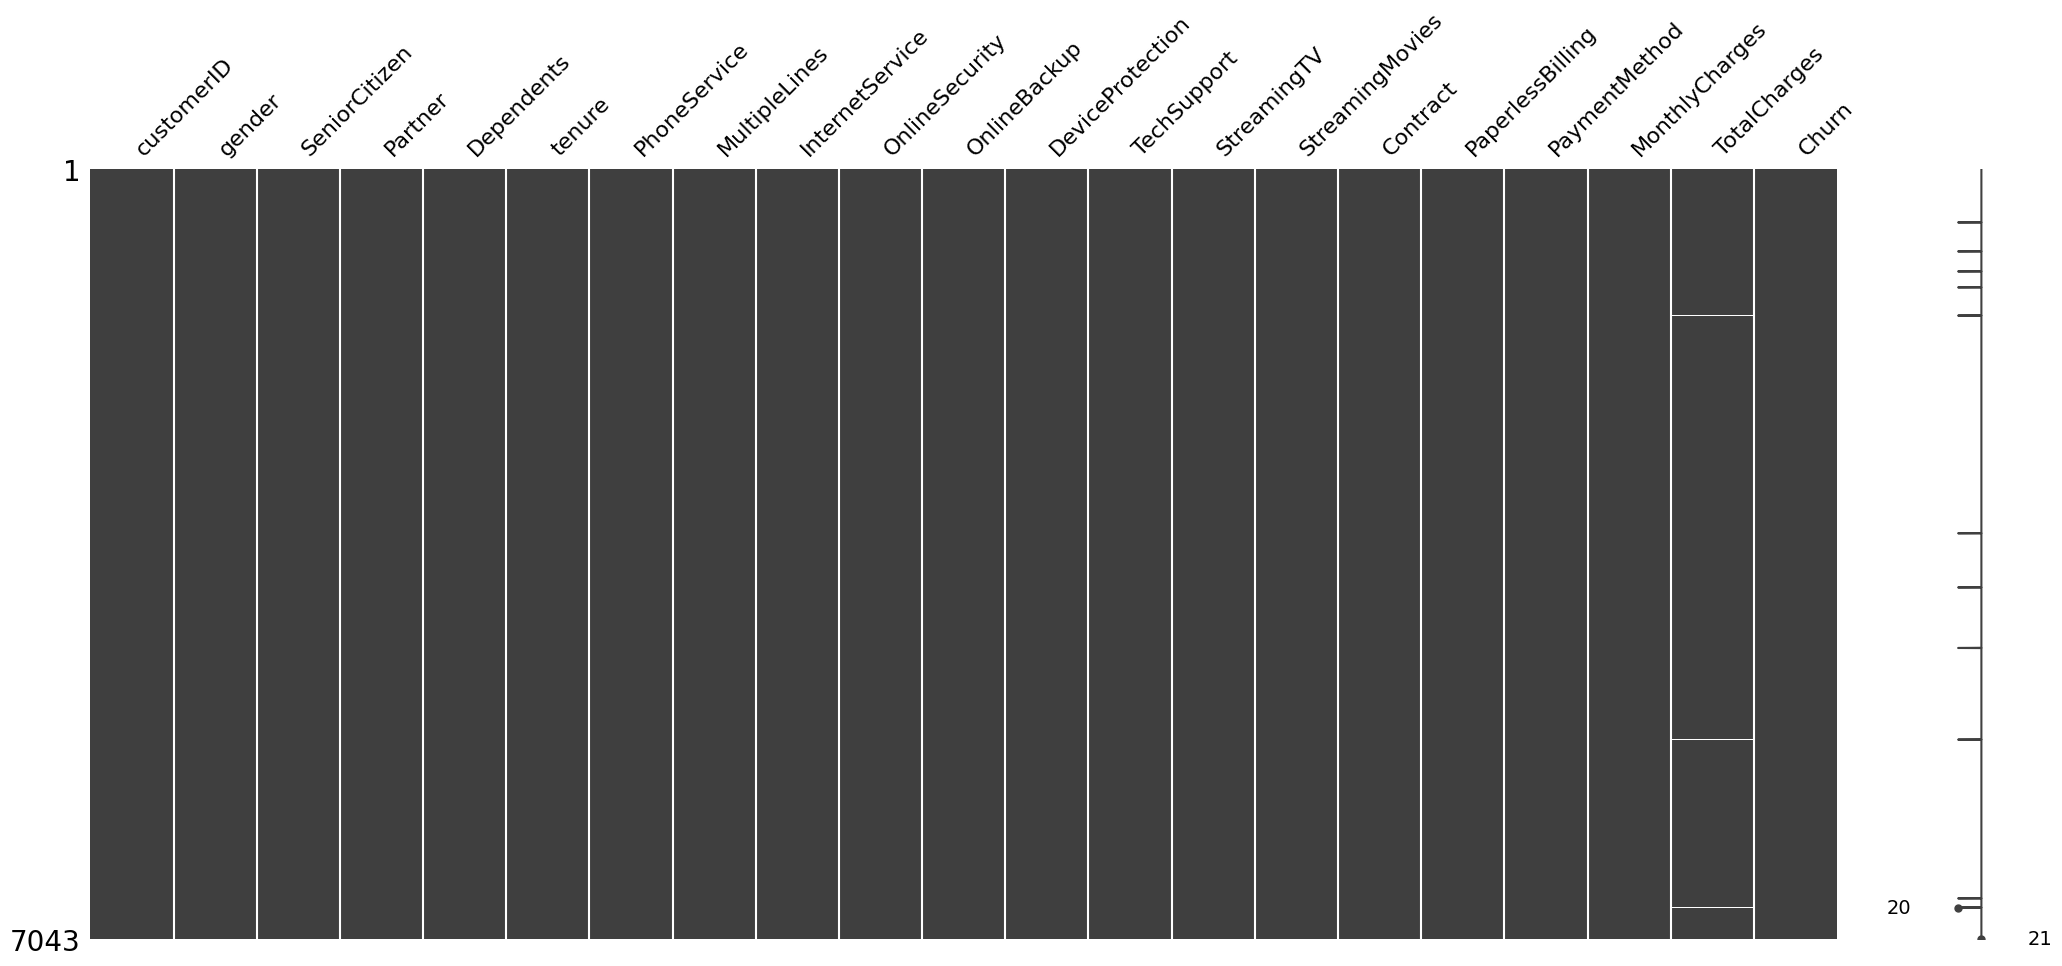

In [15]:
# Visualisierung 
msno.matrix(df);

In [16]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Wir beobachten, dass die Spalte "tenure" 0 ist bei diesen Einträgen, wo "TotalCharges" NaN ist, obwohl die Spalte MonthlyCharges nicht leer ist.

Lass uns die Spalte "tenure" näher anschauen und checken, ob es noch andere 0-Werte in diese Spalte gibt.

In [17]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

### Feststellung und Entscheidung 

Der Vergleich zeigt, dass es keine zusätzlichen fehlenden Werte in der "tenure"-Spalte gibt.

Wir löschen die Zeilen mit den fehlenden Werten in "tenure" und "TotalCharges", da es nur 11 von 7043 Zeilen sind und wir nicht von gravierenden Konsequenzen durch das Löschen dieser Zeilen ausgehen.

Wenn es nur die fehlenden Werte in "TotalCharges" wäre, könnte man auch versuchen, die Werte darin durch Extrapolation aufzufüllen mit z.B. mean.

In [18]:
# df.drop(df['tenure'] == 0, axis=0, inplace=False)

df_new = df[df["tenure"] != 0]

df_new[df_new['tenure'] == 0].index

Index([], dtype='int64')

In [19]:
df_new2 = df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=False)
df_new2[df_new2['tenure'] == 0].index

Index([], dtype='int64')

In [20]:
df_new2

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [21]:
df[df['tenure']==0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [22]:
print(df.shape)
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [23]:
df.reset_index()
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [24]:
df.reset_index(inplace=True) 
df

,index,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [25]:
if "index" in df:
    df.drop("index", axis=1, inplace=True) 
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [26]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [27]:
df[~df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [28]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## EDA - Explorative Data Analysis (Daten Exploration) 

In [29]:
df["InternetService"].describe()

count            7032
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object

In [30]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [31]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [32]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [33]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [34]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [35]:
# Anzahl der gechurnten Kunden pro Geschlecht ermitteln
print("Churned Customers")
print(df["Churn"][df["Churn"]=="Yes"].groupby(by=df["gender"]).count()) 
print()
print("Not-yet-churned Customers")
df["Churn"][df["Churn"]=="No"].groupby(by=df["gender"]).count()

Churned Customers
gender
Female    939
Male      930
Name: Churn, dtype: int64

Not-yet-churned Customers


gender
Female    2544
Male      2619
Name: Churn, dtype: int64

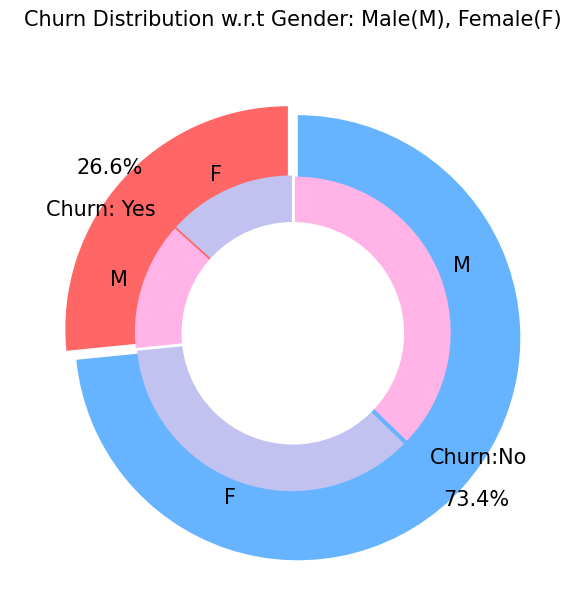

In [36]:
## Visualizierung der Churn Verteilung vs. Geschlecht 


plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["F","M","F","M"]
sizes_gender = [939,930 , 2544,2619]
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3) 
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, y=1.1)

# show plot 
 
plt.axis('equal')
plt.tight_layout()
plt.show()

In [37]:
## Visualisierung Verteilung: Churn vs. Kundenvertrag

fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Verteilung: Churn vs. Kundenvertrag<b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [38]:
# Verteilung: Churn vs. Kunden Zahlungsmethod distribution w.r.t. Churn

fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Verteilung: Churn vs. Kunden Zahlungsmethod distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Wir beobachten folgendes: 
- Die meisten Kunden, die abgewandert sind, hatten einen elektronischen Scheck als Zahlungsmethode.
- Kunden, die sich für die automatische Überweisung per Kreditkarte oder Banküberweisung und den Versand von Schecks als Zahlungsmethode entschieden, sind seltener abgewandert.

In [39]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [40]:
df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       992
Fiber optic      No       910
No               No       717
Fiber optic      Yes      633
DSL              Yes      240
No               Yes       57
Name: count, dtype: int64

In [41]:
df[df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       965
Fiber optic      No       889
No               No       690
Fiber optic      Yes      664
DSL              Yes      219
No               Yes       56
Name: count, dtype: int64

In [42]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Verteilung: Churn vs. InternetService und Geschlecht</b>")

fig.show()

Viele Kunden hatten sich für den Glasfaserdienst (Fiber optic) entschieden. Diese scheinen eine hohe Abwanderungsrate zu haben, was auf eine Unzufriedenheit mit dieser Art von Internetdienst hindeuten könnte.

Kunden, die einen DSL-Dienst nutzen, sind in der Mehrzahl und haben eine geringere Abwanderungsrate als Glasfaserkunden.

In [43]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Verteilung: Churn vs. Familienangehörige</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Es scheint, dass die Kunden ohne Familienangehörige ("dependents") wahrscheinlicher abwandern.

In [44]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Verteilung: Churn vs. Partners</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Kunden OHNE Partner scheinen eher dazu zu tendieren abzuwandern. 

In [45]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Verteilung: Churn vs. Senior Citizen</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

- Wir stellen fest, dass generell der Anteil an "seniorigen" Kunden recht niedrig ist. 
- Dazu kann man sagen, dass ein die seniorigen Kunden eher dazu tendieren abzuwandern. 


In [46]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Verteilung: Churn vs. Online Security</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Kunden OHNE Online Security tendieren stark dazu abzuwandern. 

In [47]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Verteilung: Churn vs. Papierlose Rechnung</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Kunden mit Papierlosen Zahlen scheinen dazu zu tendieren, abzuwandern.

In [48]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Verteilung: Churn vs. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Kunden OHNE TechSupport scheinen stark dazu zu tendieren abzuwandern

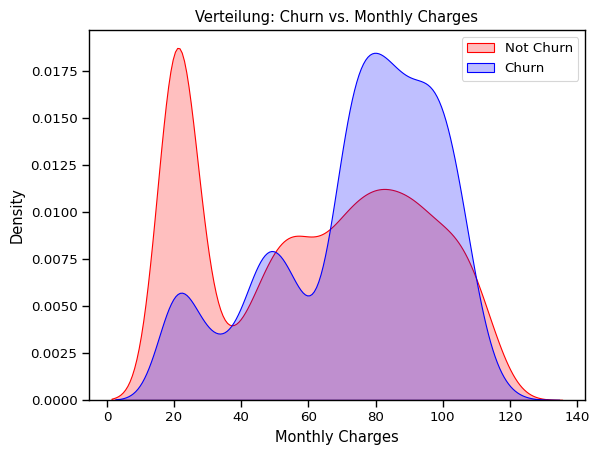

In [49]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Verteilung: Churn vs. Monthly Charges');

Kunden MIT höheren monatlichen Kosten tendieren eher dazu abzuwandern


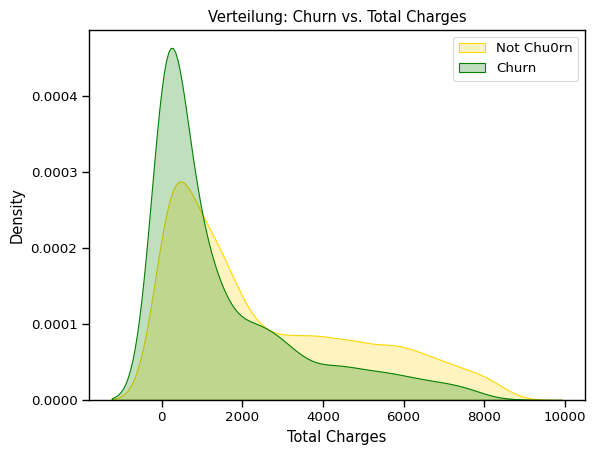

In [50]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", shade = True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", shade= True);
ax.legend(["Not Chu0rn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Verteilung: Churn vs. Total Charges');

Interessanterweise scheint der höhere Total Charge keine direkte Auswirkung auf erhöhte Abwanderungwahrscheinlichkeit zu haben.

In [51]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

NEUE Kunden scheinen tendenziell eher abzuwandern. 

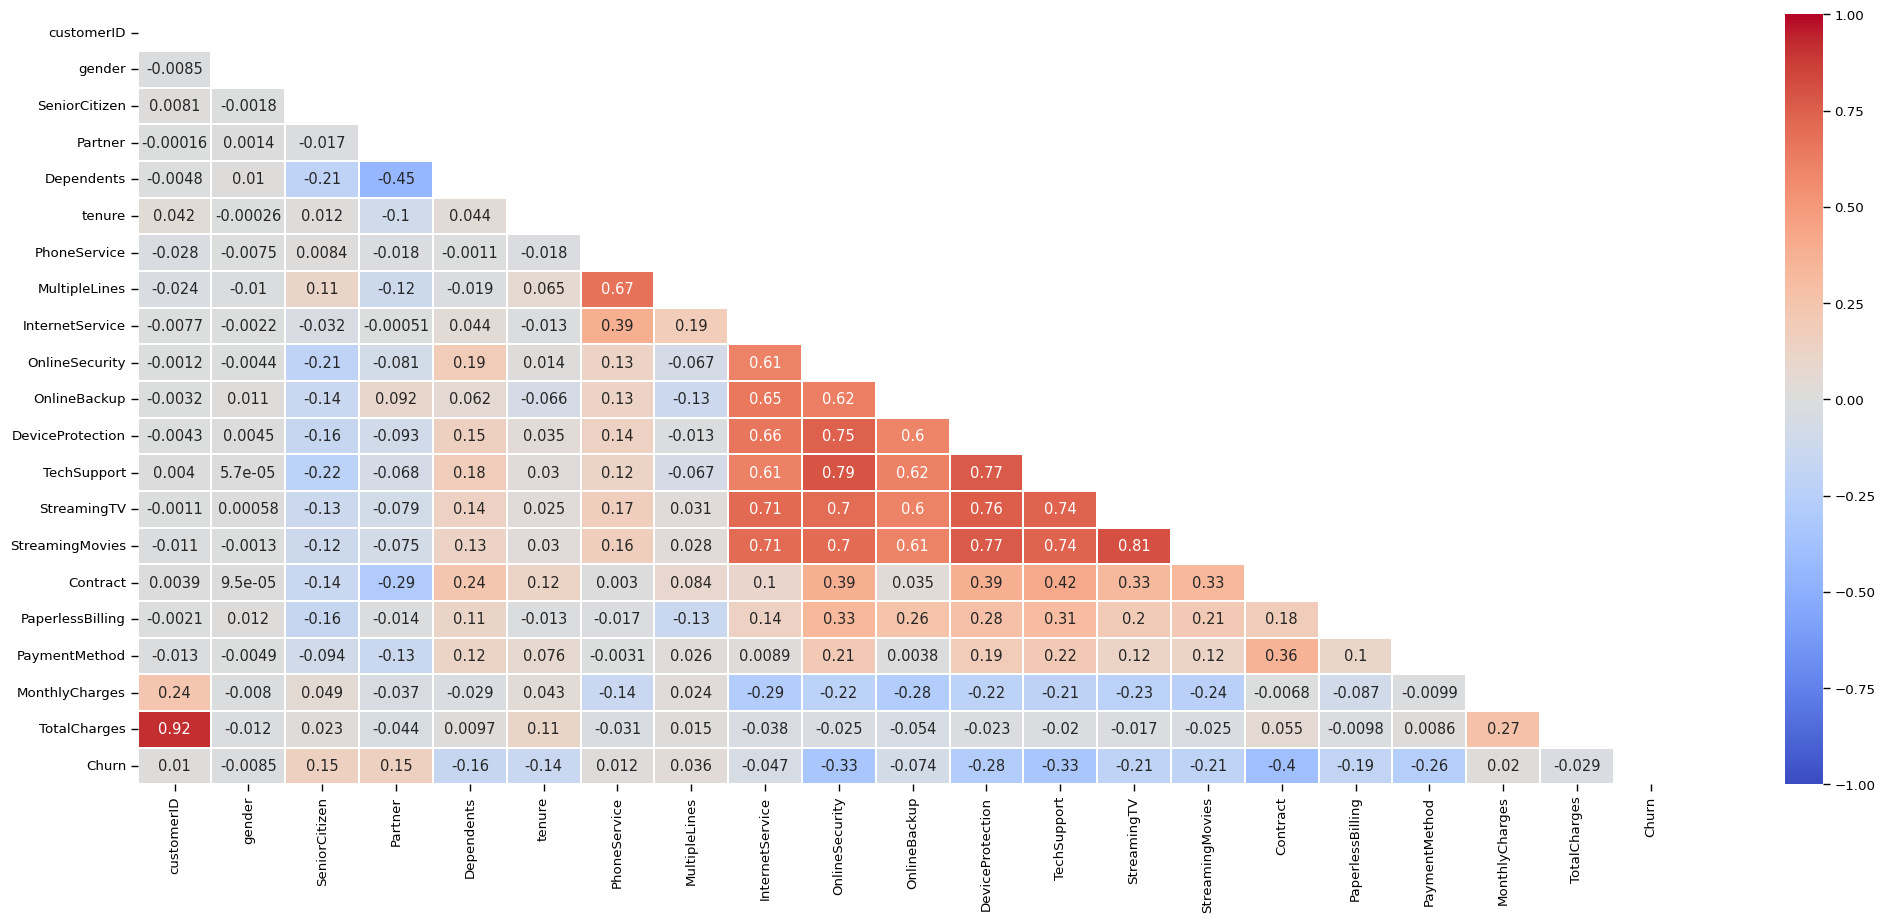

In [52]:
# Plotte den Correlation Heatmap (pandas nutzt Pearson Correlation by default)

plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

In [53]:
df.OnlineSecurity.value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

## Data Preprocessing

### Zielvariable **CHURN** 

Da es sich um ein binäres Klassifikationsproblem hanaelt, sollte die Target-Variable eine binäre Variable sein (numerisch ausgedrückt).
Da sie aktuell noch nur String ist,  wird nun die Churn-Spalte als Erstes in binary umgewandelt. 



In [54]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Wir entfernen die customerID-Spalte.

In [55]:
## Verwerfe ID-columns
if "customerID" in df:
    df.drop("customerID", axis=1, inplace=True)

df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7028,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7029,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7030,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


#### Nun haben wir uns schon sehr vieles angeschaut und viel getan ...

#### Muessten wir noch etwas tun, bevor wir die Daten splitten? Können wir den Datensatz nun direkt dem Modell zuführen? 

#### Kategorische Spalten umwandeln
Um die kategorischen Spalten richtig in numerische Spalten umzuwandeln, lass uns sie genauer anschauen und identifizieren, was sich hinter den Strings wirklich verbirgt. 

In [56]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7028,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7029,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7030,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


### DatenAnalyse:

Ist die Spalte: 

- binary? 

- boolean? 

- categorical? 

- numeric? 

### Datentypen und ihre Spalten: 

- binary: 
gender;

- boolean: 
SeniorCitizen(*), Partner, Dependents, PhoneService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling

- categorical:
MultipleLines, InternetService, Contract, PaymentMethod

- numeric:
tenure, MonthlyCharges, TotalCharges

(*)SeniorCitizen: In diesem Datensatz ist die Spalte bereits durch 0 und 1 ausgedrückt, d.h. rein rechnerisch bräuchte sie nicht nochmal extra als boolean aufgenommen werden. Allerdings sorgt es für mehr Robustheit und Stabilität in der Pipeline und somit Best Practice, doch alle Datentypen entsprechend zu identifizieren.


#### Recap: 

- **OrdinalEncoder**: gut für kategorische Werte, die eine innere Ordnung bzw Rang haben, z.B. "niedrig", "medium", "hoch" in Umfrageantworte

- **OneHotEncoder**: gut für kategorische Features ohne bestimmte innere Ordnung in einem "one-hot numerischen Array".

  **Achtung**: OneHotEncoder kann die Dimension (Anzahl Spalten) der Feature-Matrix drastisch erhöhen und "spärliche Matrizen" (scarce matrices) mit lauter "0" in der Spalte kreieren, wenn die Originalspalte viele verschieden Werte hat (hohe Kardinalität), was wiederum schlechte Datenqualität bedeuten würde.

  **Alternativen**: Es gibt auch weitere Alternativen zum One-Hot-Encoding, z.B. kann man auf *Frequency (Count) Encoding* ausweichen:

  * hier werden Kategorien basierend auf der Frequency (Häufigkeit, in denen sie auftreten) im Datensatz. Das kann helfen, die Wichtigkeit dieser Kategorie im Datensatz direkt zu erfassen und mitzugeben. Hat aber auch Pitfalls, z.B. wenn das ein biased Datensatz ist. 



**Achtung!!**
- Label-Encoder (in scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html):

  transformiert die ZIELVARIABLE in integers von 0 bis n-1 (n=Anzahl Klassen), gut geeignet bei "gleichwertigen" Klassen


### Unterteile die Columns in 3 Kategorien: Standardisierung, Ordinal-Encoding and One-Hot-Encoding

**binary** (direkte Umwandlung zu 0-1): 
gender

**boolean** (direkte Umwandlung zu 0-1): 
SeniorCitizen, Partner, Dependents, PhoneService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling

**categorical** (One-Hot oder Frequency Encoding etc):
MultipleLines, InternetService, Contract, PaymentMethod

**numeric**:
tenure, MonthlyCharges, TotalCharges

In [57]:
cols_binary = ['gender']
cols_boolean = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
cols_cat = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
cols_numeric = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [58]:
df[cols_boolean]

,SeniorCitizen,Partner,Dependents,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling
0,0,Yes,No,No,No,Yes,No,No,No,No,Yes
1,0,No,No,Yes,Yes,No,Yes,No,No,No,No
2,0,No,No,Yes,Yes,Yes,No,No,No,No,Yes
3,0,No,No,No,Yes,No,Yes,Yes,No,No,No
4,0,No,No,Yes,No,No,No,No,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...
7027,0,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes
7028,0,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes
7029,0,Yes,Yes,No,Yes,No,No,No,No,No,Yes
7030,1,Yes,No,Yes,No,No,No,No,No,No,Yes


In [59]:
df[cols_cat]

,MultipleLines,InternetService,Contract,PaymentMethod
0,No phone service,DSL,Month-to-month,Electronic check
1,No,DSL,One year,Mailed check
2,No,DSL,Month-to-month,Mailed check
3,No phone service,DSL,One year,Bank transfer (automatic)
4,No,Fiber optic,Month-to-month,Electronic check
...,...,...,...,...
7027,Yes,DSL,One year,Mailed check
7028,Yes,Fiber optic,One year,Credit card (automatic)
7029,No phone service,DSL,Month-to-month,Electronic check
7030,Yes,Fiber optic,Month-to-month,Mailed check


In [60]:
# Mapping von "Female" zu 1 und "Male" zu 0

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
df['gender']

0       1
1       0
2       0
3       0
4       1
       ..
7027    0
7028    1
7029    1
7030    0
7031    0
Name: gender, Length: 7032, dtype: int64

In [61]:
cols_boolean

['SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling']

### One-Hot-Encoding Spalten mit Werten auffüllen. 

Von den original-kartegorischen Spaltenwerten zu den neuen Werten in den neuen One-Hot-Encoded Spalten:

Wir erinnern uns: Ziel liegt darin, die die Spalten mit dem Textwert 'yes' / 'no' in numerische Binärwerte umzuwandeln

- eq('yes'):

    - vergleicht elementweise: Ist der Wert in der Spalte gleich 'yes'?
    - Ergebnis ist eine Boolean-Serie: True für 'yes', False für 'no'.
    - falls Spalte bereits als boolean vorliegt, bräuchte man das ggf nicht, da direkt multipliziert werden kann.

- mul(1)

    - elementweise Multiplikation und mappt Booleans zu Zahlen (True wird intern als 1 interpretiert und False als 0), daher wird `True * 1 => 1` und `False * 1 => 0`. Somit wird aus 'yes/no' effektiv 1/0. 
    
=> d.h. man könnte auch df[col].map({'yes':1,'no':0}) nutzen anstatt df[col].eq('yes').mul(1). 


In [62]:
for col in cols_boolean: 
    df[col] = df[col].eq('yes').mul(1)

df[cols_boolean]

,SeniorCitizen,Partner,Dependents,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling
0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,0,0,0,0,0,0,0,0
7028,0,0,0,0,0,0,0,0,0,0,0
7029,0,0,0,0,0,0,0,0,0,0,0
7030,0,0,0,0,0,0,0,0,0,0,0


In [63]:
# One-Hot-Encoding für die drei kategorischen Spalten
df_onehot_encoded = pd.get_dummies(df, columns=cols_cat) # dtype=int

print(df_onehot_encoded.shape)
df_onehot_encoded

(7032, 29)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,1,0,0,0,0,0,0,0,0,29.85,29.85,0,False,True,False,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,0,0,0,0,0,0,0,0,56.95,1889.50,0,True,False,False,True,False,False,False,True,False,False,False,False,True
2,0,0,0,0,2,0,0,0,0,0,0,0,0,53.85,108.15,1,True,False,False,True,False,False,True,False,False,False,False,False,True
3,0,0,0,0,45,0,0,0,0,0,0,0,0,42.30,1840.75,0,False,True,False,True,False,False,False,True,False,True,False,False,False
4,1,0,0,0,2,0,0,0,0,0,0,0,0,70.70,151.65,1,True,False,False,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,0,24,0,0,0,0,0,0,0,0,84.80,1990.50,0,False,False,True,True,False,False,False,True,False,False,False,False,True
7028,1,0,0,0,72,0,0,0,0,0,0,0,0,103.20,7362.90,0,False,False,True,False,True,False,False,True,False,False,True,False,False
7029,1,0,0,0,11,0,0,0,0,0,0,0,0,29.60,346.45,0,False,True,False,True,False,False,True,False,False,False,False,True,False
7030,0,0,0,0,4,0,0,0,0,0,0,0,0,74.40,306.60,1,False,False,True,False,True,False,True,False,False,False,False,False,True


In [64]:
df_onehot_encoded.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'MultipleLines_No',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Bank transfer (automatic)',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [65]:
index_label = df_onehot_encoded.columns.tolist().index('Churn')
print(df.columns.tolist()[index_label])
cols_onehot_encoded = df_onehot_encoded.columns.tolist()[index_label+1:]
print(len(cols_onehot_encoded))
cols_onehot_encoded

PaperlessBilling
13


['MultipleLines_No',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Bank transfer (automatic)',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

### One-Hot-Encoding Spalten mit Werten auffüllen. (genaue Erklärung siehe oben)

Die 'df[col].eq('yes').mul(1)' transformiert lediglich von 'yes' zu 1 und alles andere zu 0. D.h. man könnte auch df[col].map({'yes':1,'no':0}) nutzen anstatt df[col].eq('yes').mul(1). 


In [66]:
for col in cols_onehot_encoded: 
    df_onehot_encoded[col] = df_onehot_encoded[col].eq('yes').mul(1)

In [67]:
df_onehot_encoded

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,1,0,0,0,0,0,0,0,0,29.85,29.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,34,0,0,0,0,0,0,0,0,56.95,1889.50,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,2,0,0,0,0,0,0,0,0,53.85,108.15,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,45,0,0,0,0,0,0,0,0,42.30,1840.75,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,2,0,0,0,0,0,0,0,0,70.70,151.65,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,0,24,0,0,0,0,0,0,0,0,84.80,1990.50,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7028,1,0,0,0,72,0,0,0,0,0,0,0,0,103.20,7362.90,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7029,1,0,0,0,11,0,0,0,0,0,0,0,0,29.60,346.45,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7030,0,0,0,0,4,0,0,0,0,0,0,0,0,74.40,306.60,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## Split the Data to x_train, x_test, y_train, y_test

In [68]:
# Split X and y
X = df_onehot_encoded.drop(columns = ['Churn'])
y = df_onehot_encoded['Churn'].values

In [69]:
# Splitting the data into train and test sets¶
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 42, stratify=y)

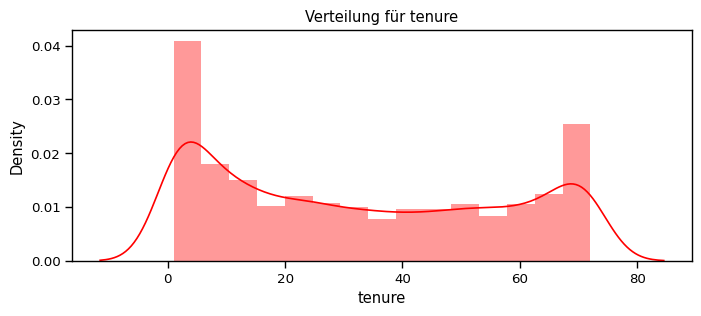

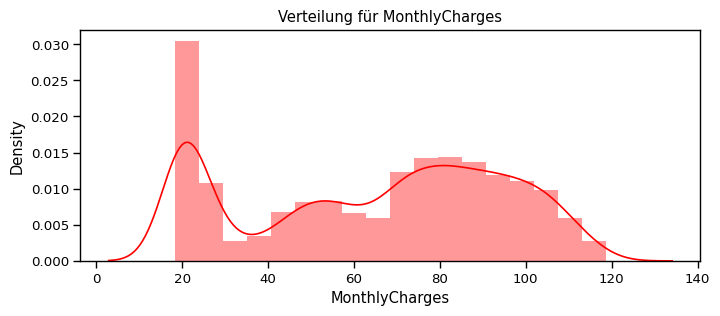

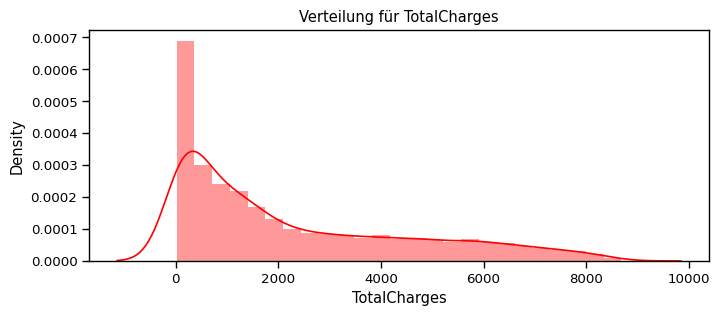

In [70]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Verteilung für {}".format(feature))
    ax = sns.distplot(frame[feature], color= color)

num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

### Überlegung: Welchen Scaler sollte ich nutzen? 
Da die numerischen Features über verschiedene Wertebereiche (value ranges) verteilt sind, können wir hier den Standard Scalar nutzen, um sie alle auf den gleichen Bereich runterzuskalieren.

## Normalisiere die numerischen Attribute

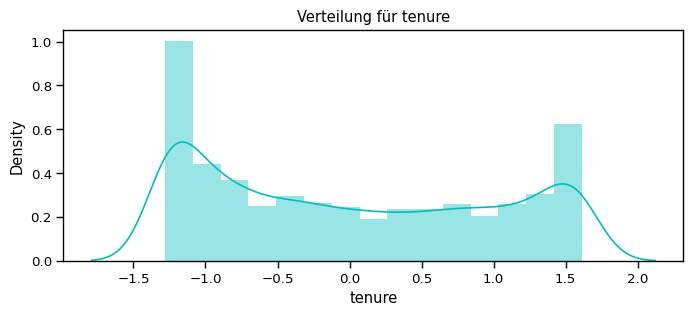

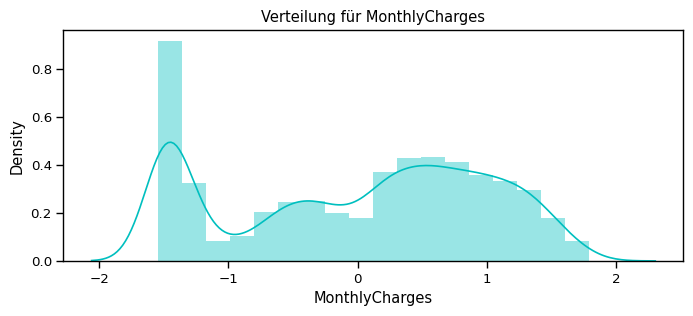

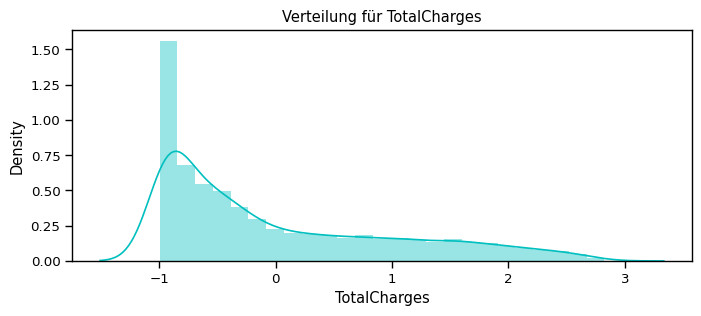

In [71]:
df_std = pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')),
                       columns=num_cols)
for feat in numerical_cols: distplot(feat, df_std, color='c')

...

In [72]:
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Modellieren
Es handelt sich hierbei um einen Datensatz mit klar definierten Labels (Churn: Yes oder No), die eine Klassifikationsproblematik beschreiben. 

Dazu werden wir nun mehrere Klassifikationsmodelle testen.

### K-Nearest Neighbor Classifier

Der K-Nearest-Neighbor Classifier ist eine nichtparametrische Methode zur Schätzung von Wahrscheinlichkeitsdichtefunktionen, mehr Details: 
https://de.wikipedia.org/wiki/N%C3%A4chste-Nachbarn-Klassifikation

Hier nutzen wir die kNN-Implemtation von scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [73]:
# Initiere das knn-Modell
knn_model = KNeighborsClassifier(n_neighbors = 11) 

In [74]:
# Trainiere das Modell mit unseren Trainingsdaten
knn_model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=11)

In [75]:
# die "score"-Funktion scoret direkt die predicted Resultate vom X_test gegen die wahren y-Werte und gibt die Accuracy zurück
accuracy_knn = knn_model.score(X_test,y_test)
print("KNN accuracy:",accuracy_knn)
print(knn_model.score(X_test,y_test))

KNN accuracy: 0.7611374407582938
0.7611374407582938


In [93]:
# Alternativ kann man direkt mit dem Modell auf den X_test (Testdatensatz) vorhersagen und diese Vorhersagen gegen die wahren Werte des Testdatensatzes mit sklearn evaluieren

y_pred = knn_model.predict(X_test)
prec = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
print("precision: ", prec)
print("recall: ", recall)

precision:  [0.81119714 0.56612529]
recall:  [0.87927695 0.43493761]


In [77]:
# Zudem gibt es den "Classification Report", der direkt mehrere Metriken Resultate ausgibt

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1549
           1       0.57      0.43      0.49       561

    accuracy                           0.76      2110
   macro avg       0.69      0.66      0.67      2110
weighted avg       0.75      0.76      0.75      2110



In [78]:
# Predict directly with the trained model

y_pred = knn_model.predict(X_test)
print(y_pred)

[0 1 0 ... 0 0 0]


### Logistic Regression Classifier

Der Logistic Regression Classifier basiert auf Linear Regression, nur gibt sie am Ende eine 


In [79]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)
accuracy_lr = lr_model.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr)

Logistic Regression accuracy is : 0.776303317535545


In [80]:
# Make predictions
lr_pred= lr_model.predict(X_test)
report = classification_report(y_test,lr_pred)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.90      0.86      1549
           1       0.61      0.42      0.50       561

    accuracy                           0.78      2110
   macro avg       0.71      0.66      0.68      2110
weighted avg       0.76      0.78      0.76      2110



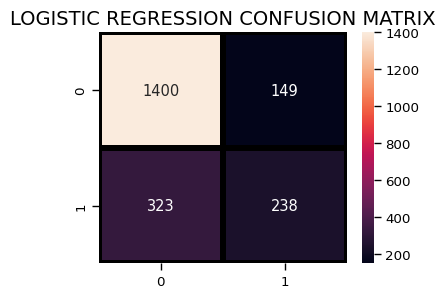

In [81]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",fontsize=14)
plt.show()

### Decision Tree Classifier¶


In [82]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
predictdt_y = dt_model.predict(X_test)
accuracy_dt = dt_model.score(X_test,y_test)
print("Decision Tree accuracy is :",accuracy_dt)

Decision Tree accuracy is : 0.704265402843602


In [83]:
print(classification_report(y_test, predictdt_y))

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1549
           1       0.45      0.46      0.45       561

    accuracy                           0.70      2110
   macro avg       0.62      0.63      0.63      2110
weighted avg       0.71      0.70      0.71      2110



### AdaBoost Classifier¶


In [84]:
a_model = AdaBoostClassifier()
a_model.fit(X_train,y_train)
a_preds = a_model.predict(X_test)
print("AdaBoost Classifier accuracy")
metrics.accuracy_score(y_test, a_preds)

AdaBoost Classifier accuracy


0.7838862559241706

In [85]:
print(classification_report(y_test, a_preds))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.63      0.47      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.70      2110
weighted avg       0.77      0.78      0.77      2110



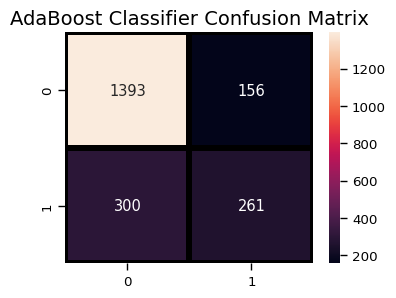

In [86]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, a_preds),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("AdaBoost Classifier Confusion Matrix",fontsize=14)
plt.show()

### Gradient Boosting Classifier¶



In [87]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting Classifier", accuracy_score(y_test, gb_pred))

Gradient Boosting Classifier 0.7781990521327015


In [88]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.62      0.44      0.51       561

    accuracy                           0.78      2110
   macro avg       0.72      0.67      0.68      2110
weighted avg       0.76      0.78      0.76      2110



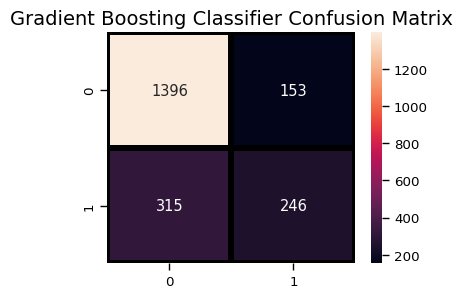

In [89]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, gb_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("Gradient Boosting Classifier Confusion Matrix",fontsize=14)
plt.show()

### Voting Classifier

Der Voting Classifier ist ein Mixture Modell, der mehrere Modelle vereint, die alle ihre Predictions machen und dann über Majority voting entschieden wird, welche Prediction Output rausgegeben wird. 



In [90]:
from sklearn.ensemble import VotingClassifier
clf1 = GradientBoostingClassifier()
clf2 = LogisticRegression()
clf3 = AdaBoostClassifier()
eclf1 = VotingClassifier(estimators=[('gbc', clf1), ('lr', clf2), ('abc', clf3)], voting='soft')
eclf1.fit(X_train, y_train)
predictions = eclf1.predict(X_test)
print("Final Accuracy Score ")
print(accuracy_score(y_test, predictions))

Final Accuracy Score 
0.7834123222748816


In [91]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1549
           1       0.63      0.44      0.52       561

    accuracy                           0.78      2110
   macro avg       0.73      0.67      0.69      2110
weighted avg       0.77      0.78      0.77      2110



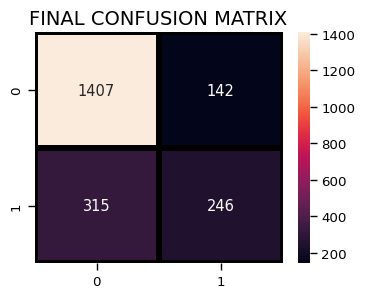

In [92]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predictions),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("FINAL CONFUSION MATRIX",fontsize=14)
plt.show()